<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; text-align:center; margin:0'>Reconocimiento de Patrones</h1>
<h2 style='color:#ffcccc; text-align:center; margin:5px 0 0 0'>Challenge 4 — Árboles de Decisión, Random Forest y XGBoost</h2>
<p style='color:#ffaaaa; text-align:center; margin:5px 0 0 0'>Ingeniería Biomédica · UPCH · 2026-1</p>
</div>

## Contexto clínico

Retomamos el dataset **Heart Failure Prediction** (Kaggle, fedesoriano, 2021) que ya conoces del Challenge 1.
En ese challenge lo exploraste y preprocesaste; aquí tu misión es **construir, analizar y comparar modelos basados en árboles**.

La pregunta clínica sigue siendo la misma: dado el perfil de un paciente (**Edad, Colesterol, ST_Slope, MaxHR...**), ¿podemos predecir si tiene enfermedad cardíaca?

Los árboles de decisión son especialmente poderosos en datos biomédicos tabulares porque:
- **Son interpretables**: el médico puede trazar exactamente cómo se llegó a un diagnóstico.
- **Capturan no-linealidades** y umbrales clínicos (ej: Oldpeak > 1.5 → riesgo elevado).
- **Random Forest y XGBoost** extienden esta idea con ensambles que reducen el sobreajuste.

---
> **Dataset:** `heart.csv` (ya descargado desde el Challenge 1)  
> **Fuente:** fedesoriano. (2021). *Heart Failure Prediction Dataset*. Kaggle. https://www.kaggle.com/fedesoriano/heart-failure-prediction  
> **Variables:** Age, Sex, ChestPainType, RestingBP, Cholesterol, FastingBS, RestingECG, MaxHR, ExerciseAngina, Oldpeak, ST_Slope → **HeartDisease** (0/1)

### Estructura de carpetas
```
Clase5_Challenge4/
├── Challenge4_ApellidoNombre.ipynb
└── heart.csv     ← el mismo del Challenge 1
```

---
---
## Ejercicio 1 — Diseño previo al código

### 1.1 — Diagnóstico esperado

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

Antes de escribir una línea de código, responde las siguientes preguntas:

**1. ¿Un árbol de decisión profundo tiene más sesgo o más varianza que un árbol *prepodado* (profundidad controlada)? Relaciona con la descomposición sesgo-varianza:**

$$\text{Error esperado}(x) = \underbrace{\left(y^\star - \mathbb{E}[y]\right)^2}_{\text{sesgo}^2} + \underbrace{\text{Var}(y)}_{\text{varianza}} + \underbrace{\text{Var}(t)}_{\text{error de Bayes}}$$

**📝 Tu respuesta (edita esta celda):**  
Árbol profundo   → sesgo + / varianza -
Árbol prepodado → sesgo - / varianza +
Justificación: Los árboles profundos son más propensos al overfitting y a aprender los sesgos del dataset. En los prepodados como se puede controlar la cantidad de subárboles, no se aprenderan estas tendencias y se podrá generalizar en grupos más amplios lo que conlleva a una mayor varianza.

---

**2. ¿Qué diferencia hay entre Gini e Entropía como criterios de división? ¿Cuándo llevan a árboles distintos?**

| Criterio | Fórmula | Rango (2 clases) |
|---|---|---|
| Gini | $1-\sum(p_i)^2$ | 0 a 0.5 |
| Entropía | $-\sum(p_i)log_2(p_i)$ | 0 a 1 |

**📝 Tu respuesta:** Gini es exponencial, se utiliza cuando hay grandes volúmenes de datos y es más eficiente computacionalmente, mientras que la Entropía se usa en menores volúmenes y utiliza logaritmos. Llevarán a árboles distintos cuando se busque priorizar la precisión ya que entropía es la que lleva la ventaja en esos casos.

---

**3. ¿Por qué Random Forest reduce la varianza pero NO el sesgo?**

Pista: $\bar{y} = \frac{1}{M}\sum_{m=1}^M y_m$ — ¿qué pasa con $\mathbb{E}[\bar{y}]$ y con $\text{Var}(\bar{y})$?

**📝 Tu respuesta:** Esto se debe al uso del promedio. El sesgo se mantiene pues el esperado del promedio es igual al sesgo esperado de cada árbol individualmente. La varianza se reduce porque al promediar muchos árboles, disminuye comparada con el caso de un árbol individual.
---

**4. Completa la tabla comparando bagging (RF) y boosting (XGBoost):**

| | Bagging / RF | Boosting / XGBoost |
|---|---|---|
| Entrenamiento | Paralelo | En serie |
| Objetivo (sesgo/varianza) | Reducir varianza, no sesgo | Reducción de sesgo y varianza|
| Riesgo principal | Underfitting | Overfitting |

---

**5. ¿Qué features del dataset heart.csv (que ya conoces del Challenge 1) esperas que sean las más importantes para predecir HeartDisease? Justifica clínicamente.**

**📝 Tu respuesta:** Edad, MaxHR y OldPeak. Clínicamente, la mayor edad a partir de los 50 años está asociada a mayor riesgo cardiovascular. Adicionalmente, valores altos de frecuencia cardiaca en reposo indican ya anormalidad que puede ser señal de enfermedad cardiaca. Finalmente, OldPeak como variable es indicador de la depresión del segmento ST, valores altos de este pueden ser signo de isquemia severa.


### 1.2 — Matemática de la impureza

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

Usando las fórmulas de **Gini** e **Entropía**:

$$G(n) = 1 - \sum_k p_k^2 \qquad H(n) = -\sum_k p_k \log_2 p_k$$

**Calcula para un nodo con 20 pacientes: 10 con enf. (pos), 10 sin enf. (neg):**

$$G(\text{raíz}) = 1 - (0.5)^2 - (0.5)^2 = 0.5$$

$$H(\text{raíz}) = -(0.5)\log_2(0.5) - (0.5)\log_2(0.5) = 1\text{ bit}$$

---

**Después de dividir por "ST\_Slope\_Up = 1":**

| Rama | Muestras | $p_+$ | Gini | Entropía |
|---|---|---|---|---|
| Izq (ST_Slope_Up=1) | 10 | 1| 0 | 0|
| Der (ST_Slope_Up=0) | 10 | 0 | 0 | 0 |

**Reducción de impureza / ganancia de información:**

$$\Delta Gini = G(\text{raíz}) - \left(\frac{10}{20}\times G(\text{Izq}) + \frac{10}{20}\times G(\text{Der})\right) = 0.5$$

$$IG_H = H(\text{raíz}) - \left(\frac{10}{20}\times H(\text{Izq}) + \frac{10}{20}\times H(\text{Der})\right) = 1 \text{ bit}$$

**📝 Completa los blancos arriba.**


### 1.3 — Pipeline completo

Completa el diagrama de pipeline para este challenge:

```
heart.csv
    │
    ▼
[ Paso A ] EDA
    │
    ▼
[ Paso B ] Train/Test split estratificado (80/20)
           ← AQUÍ se divide. ¿Por qué es importante este orden?
           📝 Tu respuesta: Para primero con EDA tener un dataset útil y limpio. Luego con la división evitar el data leakage en el testeo y que no afecte al medir el desempeño del modelo
    │
    ├─── TRAIN (80%) ───────────────────────────────────────────────────┐
    │                                                                   │
    ▼                                                                   │
[ Paso C ] Escalado y normalización                                     │
    │                                                                   │
    ▼                                                                   │
[ Paso D ] Modelos: Árbol de decisión, random Forest y XG Boost         │
    │                                                                   │
    └─── TEST (20%) ────────────────────────────────────────────────────┘
    │
    ▼
[ Paso E ] Evaluación del rendimiento: métricas y matriz de confusión
```

**📝 Tu respuesta (edita esta celda):** completa los blancos del diagrama.

---
## Ejercicio 2 — Setup y carga de datos

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

In [60]:
# ── Conexión con Google Drive ──────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Paso 2.1 — Librerías

In [61]:
UPCH_RED    = '#8B0000'
UPCH_BLUE   = '#1565C0'
UPCH_GREEN  = '#2E7D32'
UPCH_ORANGE = '#E65100'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# TODO 1: importa DecisionTreeClassifier, plot_tree desde sklearn.tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

# TODO 2: importa RandomForestClassifier desde sklearn.ensemble
from sklearn.ensemble import RandomForestClassifier

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold)
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, auc, classification_report)

# XGBoost
try:
    from xgboost import XGBClassifier
    print('XGBoost disponible ✓')
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'xgboost', '-q'])
    from xgboost import XGBClassifier
    print('XGBoost instalado ✓')

plt.rcParams['figure.dpi'] = 120
BASE = Path('/content/drive/MyDrive/Challenges/Challenge_4')
print('Setup completo ✓')

XGBoost disponible ✓
Setup completo ✓


### Paso 2.2 — Carga del dataset

In [62]:
# ── Carga del dataset ──────────────────────────────────────────
df_raw = pd.read_csv(BASE / 'heart.csv')
print(f'Shape: {df_raw.shape}')
print(f'Columnas: {list(df_raw.columns)}')
df_raw.head()

Shape: (918, 12)
Columnas: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### Paso 2.3 — Preprocesamiento compacto

In [63]:
# ── Preprocesamiento compacto (recapitulando Challenge 1) ──────
df = df_raw.copy()

# 1. Cholesterol = 0 → NaN (imposible fisiológicamente)
df.loc[df['Cholesterol'] == 0, 'Cholesterol'] = np.nan

# 2. One-Hot Encoding
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# 3. Separar features y target
X_raw         = df.drop(columns='HeartDisease').values.astype(np.float64)
y             = df['HeartDisease'].values.astype(int)
feature_names = df.drop(columns='HeartDisease').columns.tolist()

# 4. Train/Test split estratificado (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

# TODO 3: imputar Cholesterol con la mediana de TRAIN (usa SimpleImputer)
# ⚠️ IMPORTANTE: fit SOLO sobre X_train, luego transform sobre X_test
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)           # fit_transform sobre train
X_test  = imputer.transform(X_test)      # transform (sin fit) sobre test

# TODO 4: escalar con StandardScaler — fit SOLO en train
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape}  (0: {(y_train==0).sum()}, 1: {(y_train==1).sum()})')
print(f'Test:  {X_test.shape}   (0: {(y_test==0).sum()},  1: {(y_test==1).sum()})')
print(f'Features ({len(feature_names)}): {feature_names[:5]} ...')

Train: (734, 15)  (0: 328, 1: 406)
Test:  (184, 15)   (0: 82,  1: 102)
Features (15): ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR'] ...


---
# PARTE 1 — Árbol de Decisión
## Ejercicio 3 — Árbol base y curva de profundidad

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

### Paso 3.1 — Árbol base (max_depth=3) y visualización

Accuracy DT (max_depth=3): 0.7609
Nodos totales: 15  |  Hojas: 8


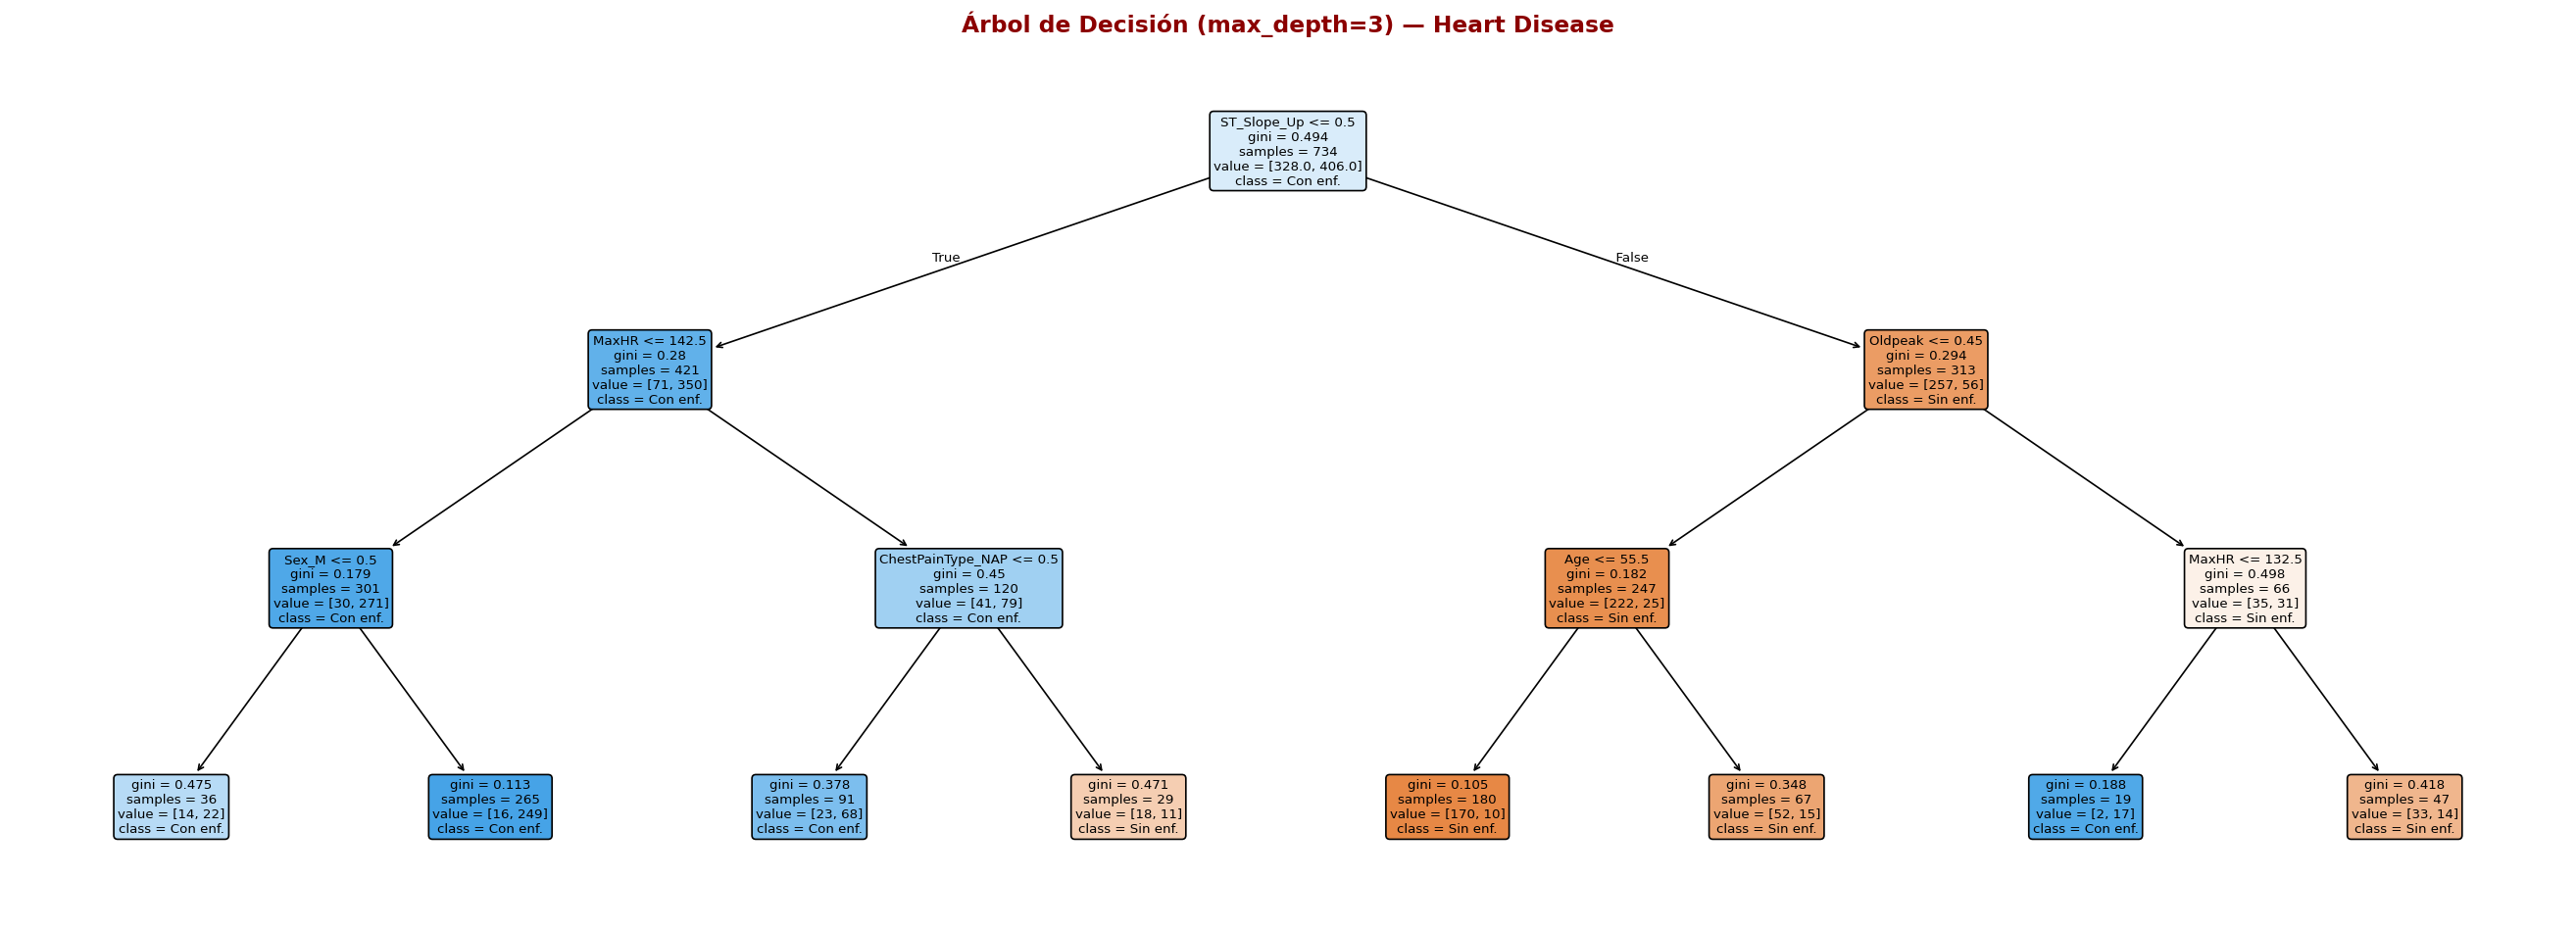

→ ¿Qué feature aparece en la raíz del árbol? ¿Tiene sentido clínicamente?
ST_Slope_Up como indicador inicial sí tiene sentido pues clínicamente el slope up es considerado saludable mientras que los planos o descendentes son indicadores de enfermedad cardiaca


In [64]:
# ── Árbol de decisión base (max_depth=3) ───────────────────────
# ⚠️ Los árboles comparan UMBRALES, no distancias → no requieren escalado
# Usamos X_train / X_test (sin escalar)

# TODO 5: crea un DecisionTreeClassifier con max_depth=3, criterion='gini',
#          min_samples_leaf=5, random_state=42
dt_base = DecisionTreeClassifier(max_depth=3, criterion='gini', min_samples_leaf=5, random_state=42)
# TODO 6: entrena el árbol sobre X_train, y_train
dt_base.fit(X_train, y_train)

y_pred_base = dt_base.predict(X_test)
acc_base    = accuracy_score(y_test, y_pred_base)
print(f'Accuracy DT (max_depth=3): {acc_base:.4f}')
print(f'Nodos totales: {dt_base.tree_.node_count}  |  Hojas: {dt_base.get_n_leaves()}')

# TODO 7: visualiza el árbol con plot_tree
#   usa: feature_names=feature_names, class_names=['Sin enf.','Con enf.'],
#        filled=True, rounded=True, fontsize=8
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(dt_base, feature_names=feature_names, class_names=['Sin enf.','Con enf.'], filled=True, rounded=True, fontsize=8)

ax.set_title('Árbol de Decisión (max_depth=3) — Heart Disease',
             fontsize=14, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('dt_visualizacion.png', dpi=150, bbox_inches='tight')
plt.show()

#####
print('→ ¿Qué feature aparece en la raíz del árbol? ¿Tiene sentido clínicamente?')
print('ST_Slope_Up como indicador inicial sí tiene sentido pues clínicamente el slope up es considerado saludable mientras que los planos o descendentes son indicadores de enfermedad cardiaca')

### Paso 3.2 — Curva de profundidad

Mejor max_depth (CV-5 en train): depth=4  →  acc_cv=0.8298


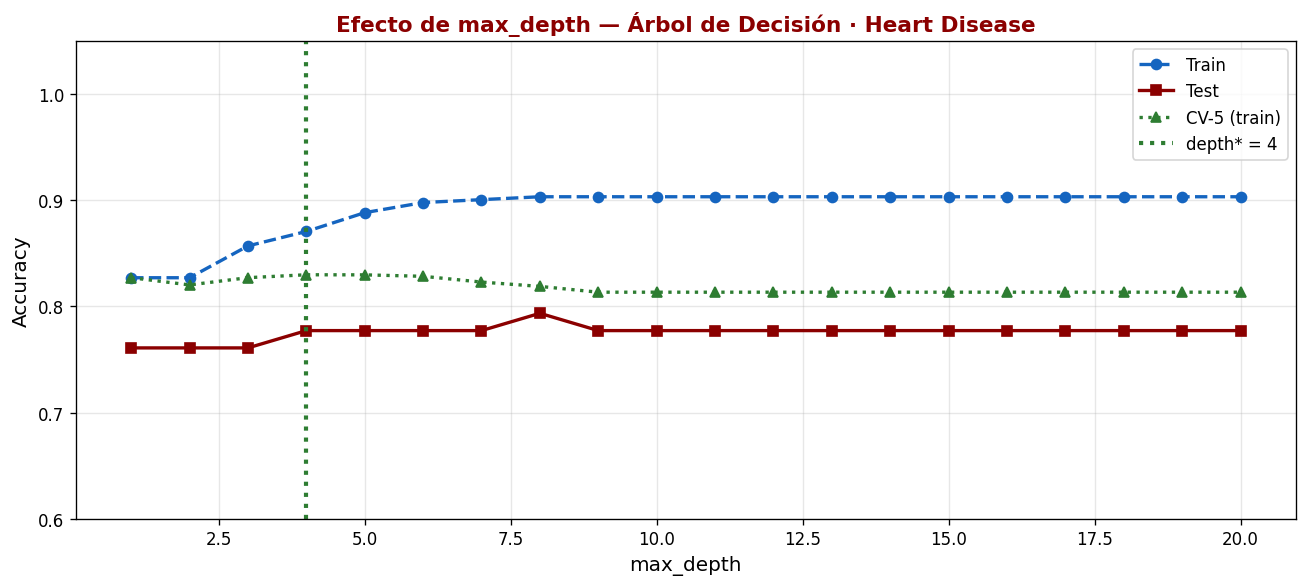

In [65]:
# ── Curva de profundidad: train vs test accuracy ────────────────
depths    = list(range(1, 21))
acc_train = []
acc_test  = []
acc_cv    = []

cv_depth = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for d in depths:
    # TODO 8: crea un DecisionTreeClassifier con max_depth=d,
    #         criterion='gini', min_samples_leaf=5, random_state=42
    dt = DecisionTreeClassifier(max_depth=d, criterion='gini', min_samples_leaf=5, random_state=42)
    dt.fit(X_train, y_train)

    # TODO 9: agrega la accuracy de train y de test a las listas
    acc_train.append(accuracy_score(y_train, dt.predict(X_train)))
    acc_test.append(accuracy_score(y_test, dt.predict(X_test)))

    # TODO 10: calcula la CV accuracy media SOLO sobre TRAIN
    #   usa cross_val_score con cv=cv_depth y scoring='accuracy'
    sc_cv = cross_val_score(dt, X_train, y_train, cv=cv_depth, scoring='accuracy').mean()
    acc_cv.append(sc_cv)

# Selección correcta del modelo: NO usar test para escoger max_depth
best_idx   = np.argmax(acc_cv)
best_depth = depths[best_idx]
print(f'Mejor max_depth (CV-5 en train): depth={best_depth}  →  acc_cv={acc_cv[best_idx]:.4f}')

# Gráfica
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(depths, acc_train, 'o--', color=UPCH_BLUE,  lw=2, label='Train')
ax.plot(depths, acc_test,  's-',  color=UPCH_RED,   lw=2, label='Test')
ax.plot(depths, acc_cv,    '^:',  color=UPCH_GREEN, lw=2, label='CV-5 (train)')
ax.axvline(best_depth, color=UPCH_GREEN, ls=':', lw=2.5,
           label=f'depth* = {best_depth}')
ax.set_xlabel('max_depth', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Efecto de max_depth — Árbol de Decisión · Heart Disease',
             fontsize=13, fontweight='bold', color=UPCH_RED)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.6, 1.05)
plt.tight_layout()
plt.savefig('dt_curva_profundidad.png', dpi=150, bbox_inches='tight')
plt.show()


### Paso 3.2 — Interpretación

**📝 Tu respuesta (edita esta celda):**

**1. ¿Por qué la accuracy de train sube mientras la de test cae al aumentar max_depth?**  
La accuracy de train sube pues se toman decisiones más específicas basadas en el dataset. La accuracy de test disminuye pues el modelo llega al overfitting y ya no es capaz de generalizar correctamente.

**2. ¿En qué profundidad empieza el sobreajuste? ¿Cómo lo identificas en la gráfica?**  
Empieza en la profundidad 4 porque la gráfica ya no cambia, el accuracy de train y test se mantiene estable.

**3. ¿Qué analogía clínica tiene el sobreajuste de un árbol muy profundo?**  
Tiene la analogía de un médico sesgado que memoriza casos y usa datos irrelevantes clínicamente para diagnosticar pacientes.

### Paso 3.3 — Feature Importance

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>

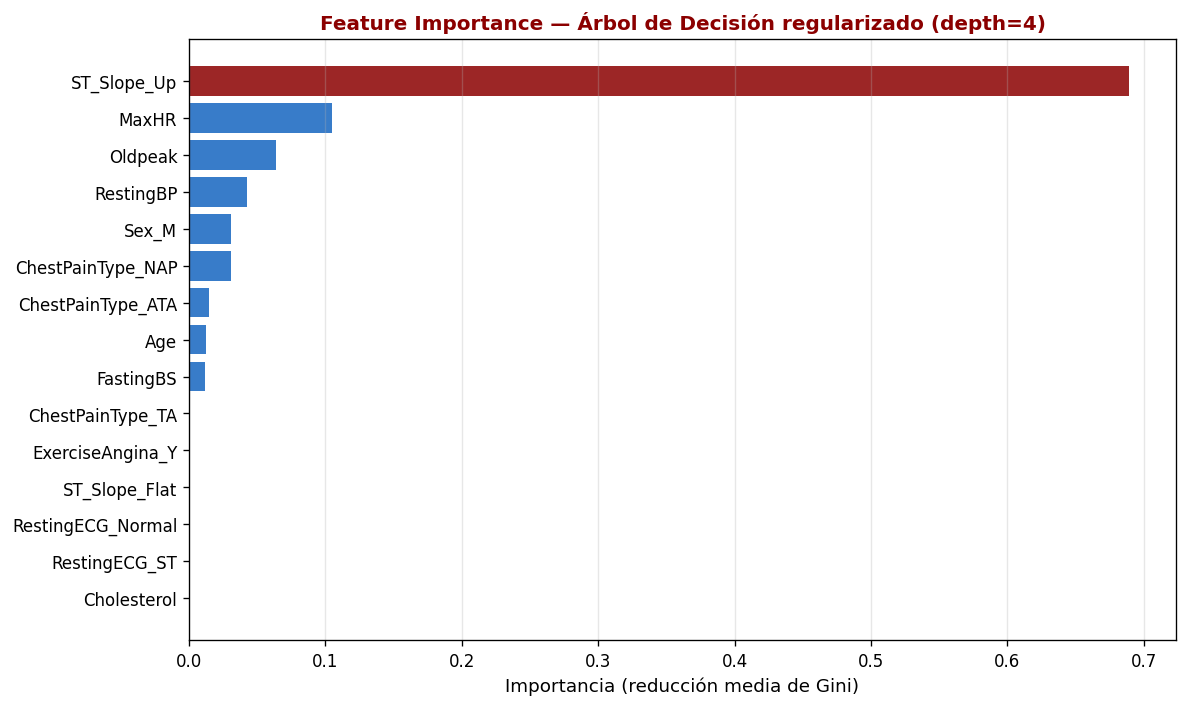

Top 5 features más importantes:
  1. ST_Slope_Up                              0.6891
  2. MaxHR                                    0.1046
  3. Oldpeak                                  0.0638
  4. RestingBP                                0.0422
  5. Sex_M                                    0.0308

→ ¿Coincide con tus predicciones clínicas del Ejercicio 1.1?
No conincide del todo puesto que la variable con mayor relevancia (0.6891) en el modelo es ST_Slope_Up y otras variables como MaxHR (0.1046) y Oldpeak (0.0638) tienen menor influencia 


In [66]:
# ── Árbol óptimo + Feature Importance ─────────────────────────
# TODO 11: crea y entrena el árbol con best_depth
dt_opt = DecisionTreeClassifier(max_depth=best_depth, criterion='gini',
                                 min_samples_leaf=5, random_state=42)
dt_opt.fit(X_train, y_train)

importances_dt = dt_opt.feature_importances_

# TODO 12: ordena las importancias de mayor a menor (usa np.argsort)
idx_sorted = np.argsort(importances_dt)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    [feature_names[i] for i in idx_sorted[::-1]],
    importances_dt[idx_sorted[::-1]],
    color=[UPCH_RED if i == 0 else UPCH_BLUE
           for i in range(len(feature_names))][::-1],
    alpha=0.85
)
ax.set_xlabel('Importancia (reducción media de Gini)', fontsize=11)
ax.set_title(f'Feature Importance — Árbol de Decisión regularizado (depth={best_depth})',
             fontsize=12, fontweight='bold', color=UPCH_RED)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('dt_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features más importantes:')
for r, i in enumerate(idx_sorted[:5]):
    print(f'  {r+1}. {feature_names[i]:<40} {importances_dt[i]:.4f}')
print()
print('→ ¿Coincide con tus predicciones clínicas del Ejercicio 1.1?')
print('No conincide del todo puesto que la variable con mayor relevancia (0.6891) en el modelo es ST_Slope_Up y otras variables como MaxHR (0.1046) y Oldpeak (0.0638) tienen menor influencia ')

### Paso 3.4 — Métricas y matriz de confusión

   Árbol de Decisión regularizado (max_depth=4)
  Accuracy : 0.7772
  Recall   : 0.7941
  Precision: 0.8020
  F1-Score : 0.7980

              precision    recall  f1-score   support

    Sin enf.       0.75      0.76      0.75        82
    Con enf.       0.80      0.79      0.80       102

    accuracy                           0.78       184
   macro avg       0.77      0.78      0.77       184
weighted avg       0.78      0.78      0.78       184



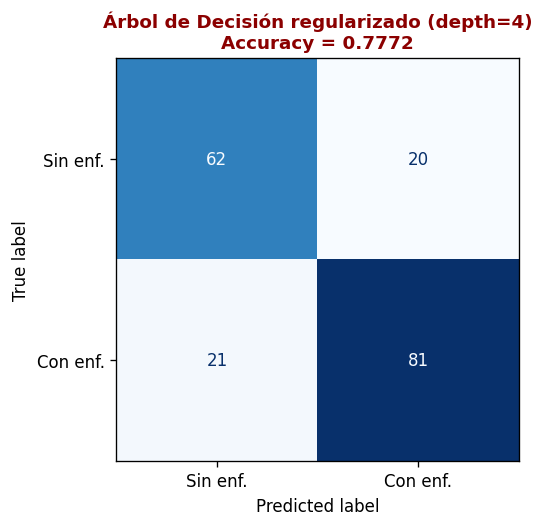

In [67]:
# ── Métricas finales Árbol de Decisión ──────────────────────────
y_pred_dt = dt_opt.predict(X_test)

# TODO 13: calcula las 4 métricas para el árbol óptimo
acc_dt  = accuracy_score(y_test, y_pred_dt)
rec_dt  = recall_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
f1_dt   = f1_score(y_test, y_pred_dt)


print('=' * 52)
print(f'   Árbol de Decisión regularizado (max_depth={best_depth})')
print('=' * 52)
print(f'  Accuracy : {acc_dt:.4f}')
print(f'  Recall   : {rec_dt:.4f}')
print(f'  Precision: {prec_dt:.4f}')
print(f'  F1-Score : {f1_dt:.4f}')
print()
print(classification_report(y_test, y_pred_dt,
                             target_names=['Sin enf.', 'Con enf.']))

# TODO 14: grafica la matriz de confusión con ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(5.5, 4.5))
cm = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sin enf.', 'Con enf.']).plot(ax=ax, cmap='Blues', colorbar=False)

ax.set_title(f'Árbol de Decisión regularizado (depth={best_depth})\nAccuracy = {acc_dt:.4f}',
             fontsize=11, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('cm_dt.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PARTE 2 — Random Forest
## Ejercicio 4 — Efecto de n_estimators y optimización

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>

### Paso 4.1 — Efecto de n_estimators

n=   1  train=0.9196  test=0.8043  OOB=N/A 
n=   5  train=0.9741  test=0.8315  OOB=0.7425
n=  10  train=0.9891  test=0.8424  OOB=0.7943
n=  20  train=0.9973  test=0.8533  OOB=0.8243
n=  50  train=0.9986  test=0.8696  OOB=0.8392
n= 100  train=1.0000  test=0.8750  OOB=0.8447
n= 200  train=1.0000  test=0.8587  OOB=0.8501
n= 300  train=1.0000  test=0.8696  OOB=0.8556


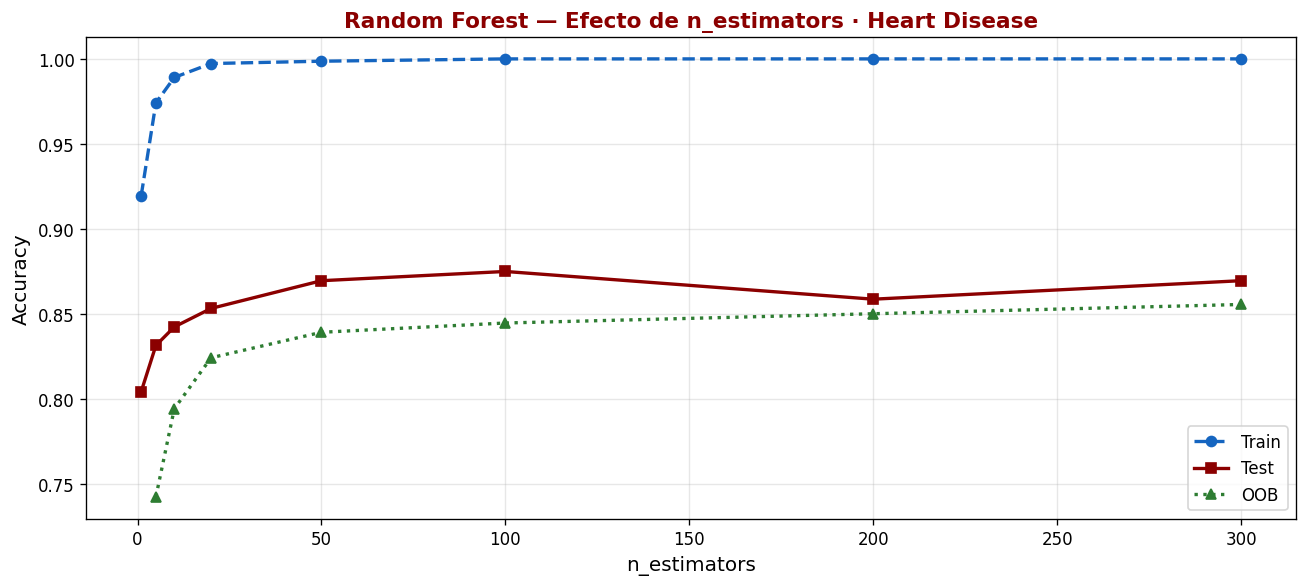

In [68]:
# ── Efecto de n_estimators en Random Forest ────────────────────
n_list = [1, 5, 10, 20, 50, 100, 200, 300]
acc_rf_train = []
acc_rf_test  = []
acc_rf_oob   = []

for n in n_list:
    # TODO 15: crea un RandomForestClassifier con n_estimators=n,
    #           max_features='sqrt', oob_score=(n>=2), random_state=42, n_jobs=-1
    rf = RandomForestClassifier(n_estimators=n, max_features='sqrt', oob_score=(n>=2), random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    acc_rf_train.append(accuracy_score(y_train, rf.predict(X_train)))
    acc_rf_test.append( accuracy_score(y_test,  rf.predict(X_test)))
    # TODO 16: agrega el OOB score (usa np.nan si n < 2)
    acc_rf_oob.append(np.nan if n < 2 else rf.oob_score_)

    oob_str = f'{acc_rf_oob[-1]:.4f}' if n >= 2 else 'N/A '
    print(f'n={n:>4}  train={acc_rf_train[-1]:.4f}  '
          f'test={acc_rf_test[-1]:.4f}  OOB={oob_str}')

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(n_list, acc_rf_train, 'o--', color=UPCH_BLUE,  lw=2, label='Train')
ax.plot(n_list, acc_rf_test,  's-',  color=UPCH_RED,   lw=2, label='Test')
ax.plot(n_list, acc_rf_oob,   '^:',  color=UPCH_GREEN, lw=2, label='OOB')
ax.set_xlabel('n_estimators', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Random Forest — Efecto de n_estimators · Heart Disease',
             fontsize=13, fontweight='bold', color=UPCH_RED)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rf_n_estimators.png', dpi=150, bbox_inches='tight')
plt.show()

### Paso 4.1 — Interpretación

**📝 Tu respuesta (edita esta celda):**

**1. ¿Por qué la accuracy de RF converge al aumentar n_estimators?**  
Pista: $\text{Var}(\bar{y}) = \left(\frac{1-\rho}{M} + \rho\right)\sigma^2$  

Porque el agregar más árboles permitte que el modelo mejore y la varianza disminuya y se estabilice, después de pasar un cierto número de árboles ya no se puede mejorar pues el error de generalización ya habría llegado a un equilibrio.
___

**2. ¿Qué es el OOB score? ¿Por qué es útil?**

Es una métrica propia de los modelos que usan bagging y usa las muestras no vistas en el entrenamiento para evaluar el rendimiento. Es útil debido a que permite evaluar un modelo sin un conjunto aparte de datos para validar y así aprovechar el dataset al máximo.

**3. ¿RF tiene más o menos sesgo que un árbol individual del mismo max_depth?**

En realidad el sesgo va a ser casi igual que el de un árbol individual pues trabajamos con promedios, lo que varía en este caso es la varianza que disminuye de manera rápida a medida que se aumenta la profundidad.
___

### Paso 4.2 — Barrido max_features × max_depth

In [69]:
# ── Random Forest optimizado (barrido max_features × max_depth) ─
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mf_list = ['sqrt', 'log2', None]
md_list = [None, 5, 10, 15]

print('Barrido max_features × max_depth (CV-5):')
print(f'{"max_features":<15} {"max_depth":<12} {"CV acc"}')
print('-' * 42)

best_score_rf = 0
best_mf, best_md = 'sqrt', None

for mf in mf_list:
    for md in md_list:
        # TODO 17: crea RandomForestClassifier con los parámetros del loop
        rf_cv = RandomForestClassifier(n_estimators=100, max_features=mf, max_depth=md,
                                      oob_score=False, random_state=42, n_jobs=-1)
        # TODO 18: calcula la CV accuracy con cross_val_score
        sc = cross_val_score(rf_cv, X_train, y_train, cv=cv, scoring='accuracy').mean()

        mf_s = str(mf) if mf else 'all'
        md_s = str(md) if md else 'None'
        print(f'{mf_s:<15} {md_s:<12} {sc:.4f}')
        if sc > best_score_rf:
            best_score_rf = sc
            best_mf, best_md = mf, md

print(f'\nMejores parámetros: max_features={best_mf}, max_depth={best_md}')
print(f'CV accuracy: {best_score_rf:.4f}')

Barrido max_features × max_depth (CV-5):
max_features    max_depth    CV acc
------------------------------------------
sqrt            None         0.8529
sqrt            5            0.8488
sqrt            10           0.8529
sqrt            15           0.8502
log2            None         0.8529
log2            5            0.8488
log2            10           0.8529
log2            15           0.8502
all             None         0.8338
all             5            0.8488
all             10           0.8379
all             15           0.8338

Mejores parámetros: max_features=sqrt, max_depth=None
CV accuracy: 0.8529


### Paso 4.3 — Random Forest final

In [70]:
# ── Random Forest final ─────────────────────────────────────────
# TODO 19: crea el RF final con n_estimators=200, best_mf, best_md,
#           oob_score=True, random_state=42, n_jobs=-1
rf_final = RandomForestClassifier(n_estimators=200, max_features=best_mf, max_depth=best_md,
                             oob_score=True, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

y_pred_rf = rf_final.predict(X_test)

# TODO 20: calcula las 4 métricas para RF
acc_rf  = accuracy_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)


print('=' * 52)
print(f'   Random Forest (n=200, mf={best_mf}, depth={best_md})')
print('=' * 52)
print(f'  OOB Score: {rf_final.oob_score_:.4f}')
print(f'  Accuracy : {acc_rf:.4f}')
print(f'  Recall   : {rec_rf:.4f}')
print(f'  Precision: {prec_rf:.4f}')
print(f'  F1-Score : {f1_rf:.4f}')
print(f'\n  Δ Accuracy vs DT: {acc_rf - acc_dt:+.4f}')

   Random Forest (n=200, mf=sqrt, depth=None)
  OOB Score: 0.8501
  Accuracy : 0.8587
  Recall   : 0.8725
  Precision: 0.8725
  F1-Score : 0.8725

  Δ Accuracy vs DT: +0.0815


### Paso 4.4 — Feature Importance: DT vs RF

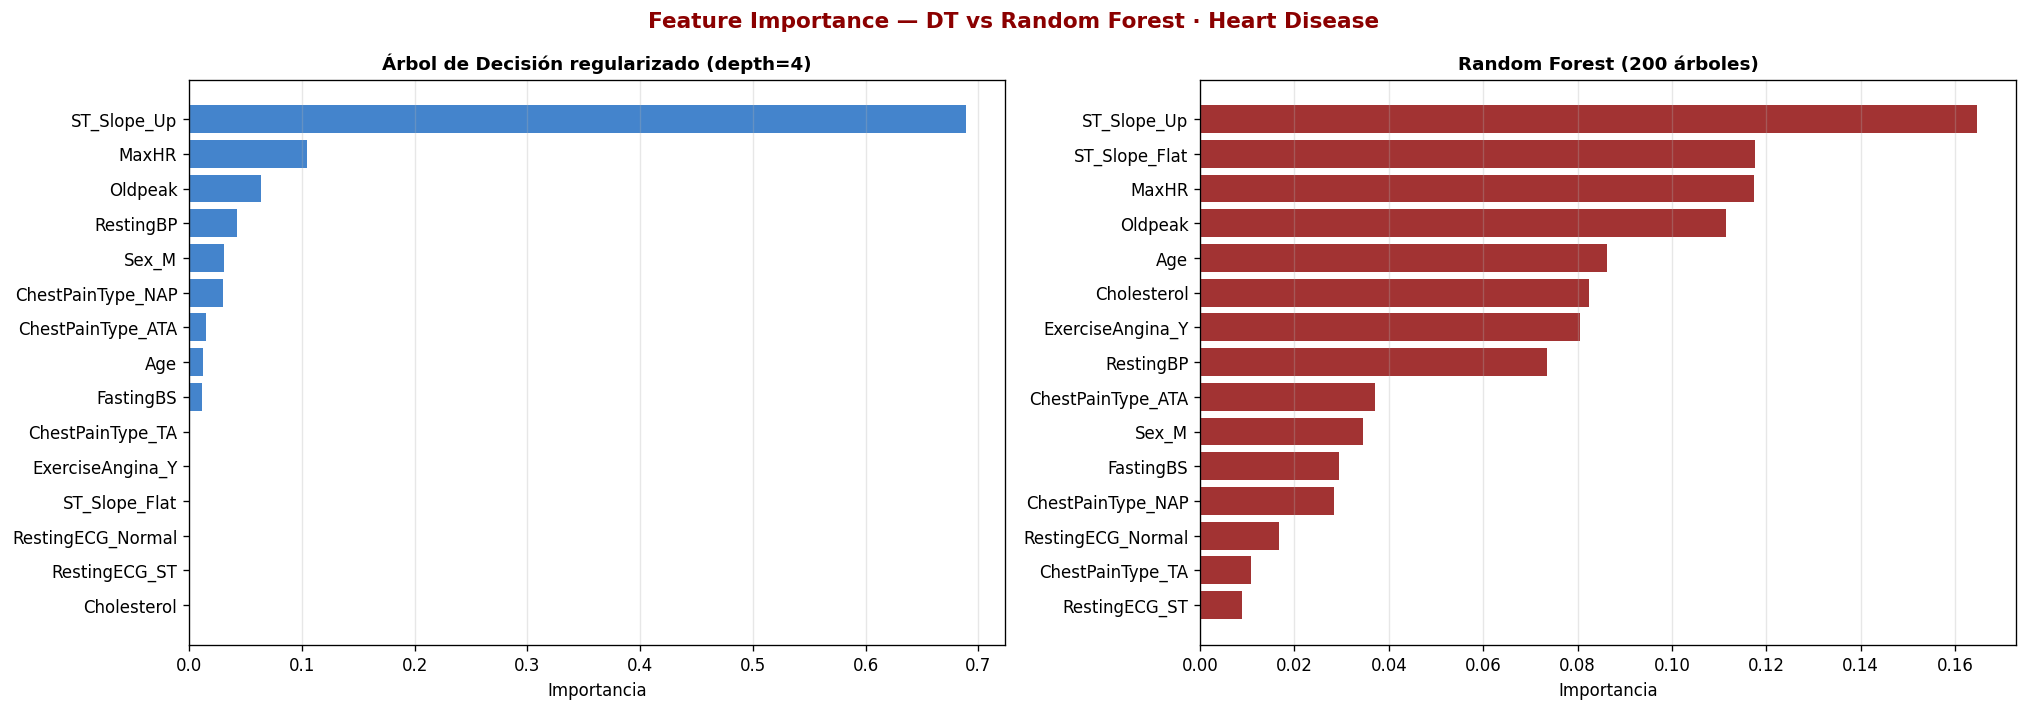

Correlación entre importancias DT y RF: 0.6325

→ ¿Las RF importancias son más o menos estables que las del DT individual?
Las importancias son más estables en el RF, se observa que los porcentajes están más equilibrados entre las características. 
Esto en general hace que nuestro modelo sea más robusto y tenga menos varianza.


In [71]:
# ── Feature Importance: DT vs RF ────────────────────────────────
# TODO 21: extrae las feature importances del RF final
importances_rf = rf_final.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
for ax, imp, title, color in zip(
    axes,
    [importances_dt, importances_rf],
    [f'Árbol de Decisión regularizado (depth={best_depth})', 'Random Forest (200 árboles)'],
    [UPCH_BLUE, UPCH_RED]
):
    idx = np.argsort(imp)
    ax.barh([feature_names[i] for i in idx], imp[idx], color=color, alpha=0.8)
    ax.set_xlabel('Importancia', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)

plt.suptitle('Feature Importance — DT vs Random Forest · Heart Disease',
             fontsize=13, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('fi_dt_vs_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Correlación entre importancias DT y RF: '
      f'{np.corrcoef(importances_dt, importances_rf)[0,1]:.4f}')
print()
print('→ ¿Las RF importancias son más o menos estables que las del DT individual?')
print('Las importancias son más estables en el RF, se observa que los porcentajes están más equilibrados entre las características. \nEsto en general hace que nuestro modelo sea más robusto y tenga menos varianza.')

---
# PARTE 3 — XGBoost
## Ejercicio 5 — Gradient Boosting

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>

### Paso 5.1 — XGBoost base

In [72]:
# ── XGBoost base ────────────────────────────────────────────────
# XGBoost actualiza secuencialmente: ĝ_m(x) = ĝ_{m-1}(x) + η·h_m(x)
# η = learning_rate; h_m = árbol que minimiza los residuos del paso anterior

# TODO 22: crea un XGBClassifier con n_estimators=100, learning_rate=0.1,
#           max_depth=4, subsample=0.8, colsample_bytree=0.8,
#           random_state=42, eval_metric='logloss', verbosity=0
xgb_base = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4,
                         subsample=0.8, colsample_bytree=0.8,
                         random_state=42, eval_metric='logloss', verbosity=0)

# TODO 23: entrena sobre X_train, y_train
xgb_base.fit(X_train, y_train)

y_pred_xgb_base = xgb_base.predict(X_test)
acc_xgb_base    = accuracy_score(y_test, y_pred_xgb_base)
print(f'Accuracy XGBoost base (lr=0.1, depth=4, n=100): {acc_xgb_base:.4f}')
print()
print('→ ¿XGBoost base supera al Árbol de Decisión y al Random Forest?')
print('Sí porque en la precisión XGBoost tiene 0.8641, mientras que los otros modelos tienen DT 0.7772 y RF 0.8587')

Accuracy XGBoost base (lr=0.1, depth=4, n=100): 0.8641

→ ¿XGBoost base supera al Árbol de Decisión y al Random Forest?
Sí porque en la precisión XGBoost tiene 0.8641, mientras que los otros modelos tienen DT 0.7772 y RF 0.8587


### Paso 5.2 — Tuning: learning_rate × n_estimators

In [73]:
# ── Tuning: barrido learning_rate × n_estimators ─────────────
lr_list    = [0.01, 0.05, 0.1, 0.2, 0.3]
n_est_list = [50, 100, 200, 300]

print('Barrido learning_rate × n_estimators (CV-5):')
print(f'{"lr":<8} {"n_est":<8} {"CV acc"}')
print('-' * 28)

best_score_xgb = 0
best_lr, best_n_xgb = 0.1, 100

for lr in lr_list:
    for n_est in n_est_list:
        # TODO 24: crea XGBClassifier con los parámetros del loop
        xgb_cv = XGBClassifier(n_estimators=n_est, learning_rate=lr, max_depth=4,
                           subsample=0.8, colsample_bytree=0.8,
                           random_state=42, eval_metric='logloss', verbosity=0)

        # TODO 25: calcula CV accuracy (cv=cv, scoring='accuracy')
        sc = cross_val_score(xgb_cv, X_train, y_train, cv=cv, scoring='accuracy').mean()

        print(f'{lr:<8} {n_est:<8} {sc:.4f}')
        if sc > best_score_xgb:
            best_score_xgb = sc
            best_lr, best_n_xgb = lr, n_est

print(f'\nMejores parámetros: lr={best_lr}, n_estimators={best_n_xgb}')
print(f'CV accuracy: {best_score_xgb:.4f}')

Barrido learning_rate × n_estimators (CV-5):
lr       n_est    CV acc
----------------------------
0.01     50       0.8502
0.01     100      0.8529
0.01     200      0.8556
0.01     300      0.8624
0.05     50       0.8570
0.05     100      0.8706
0.05     200      0.8706
0.05     300      0.8747
0.1      50       0.8651
0.1      100      0.8733
0.1      200      0.8556
0.1      300      0.8624
0.2      50       0.8569
0.2      100      0.8569
0.2      200      0.8569
0.2      300      0.8569
0.3      50       0.8583
0.3      100      0.8542
0.3      200      0.8488
0.3      300      0.8556

Mejores parámetros: lr=0.05, n_estimators=300
CV accuracy: 0.8747


### Paso 5.3 — XGBoost final

In [74]:
# ── XGBoost final ───────────────────────────────────────────────
# TODO 26: crea el XGBClassifier final con los mejores parámetros
xgb_final = XGBClassifier(n_estimators=best_n_xgb, learning_rate=best_lr, max_depth=4,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=42, eval_metric='logloss', verbosity=0)

xgb_final.fit(X_train, y_train)

y_pred_xgb = xgb_final.predict(X_test)

# TODO 27: calcula las 4 métricas para XGBoost
acc_xgb  = accuracy_score(y_test, y_pred_xgb)
rec_xgb  = recall_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
f1_xgb   = f1_score(y_test, y_pred_xgb)

print('=' * 55)
print(f'   XGBoost (lr={best_lr}, n={best_n_xgb}, depth=4)')
print('=' * 55)
print(f'  Accuracy : {acc_xgb:.4f}')
print(f'  Recall   : {rec_xgb:.4f}')
print(f'  Precision: {prec_xgb:.4f}')
print(f'  F1-Score : {f1_xgb:.4f}')
print(f'\n  Δ Accuracy vs DT: {acc_xgb - acc_dt:+.4f}')
print(f'  Δ Accuracy vs RF: {acc_xgb - acc_rf:+.4f}')

   XGBoost (lr=0.05, n=300, depth=4)
  Accuracy : 0.8587
  Recall   : 0.8431
  Precision: 0.8958
  F1-Score : 0.8687

  Δ Accuracy vs DT: +0.0815
  Δ Accuracy vs RF: +0.0000


### Paso 5.4 — Feature Importance comparativa

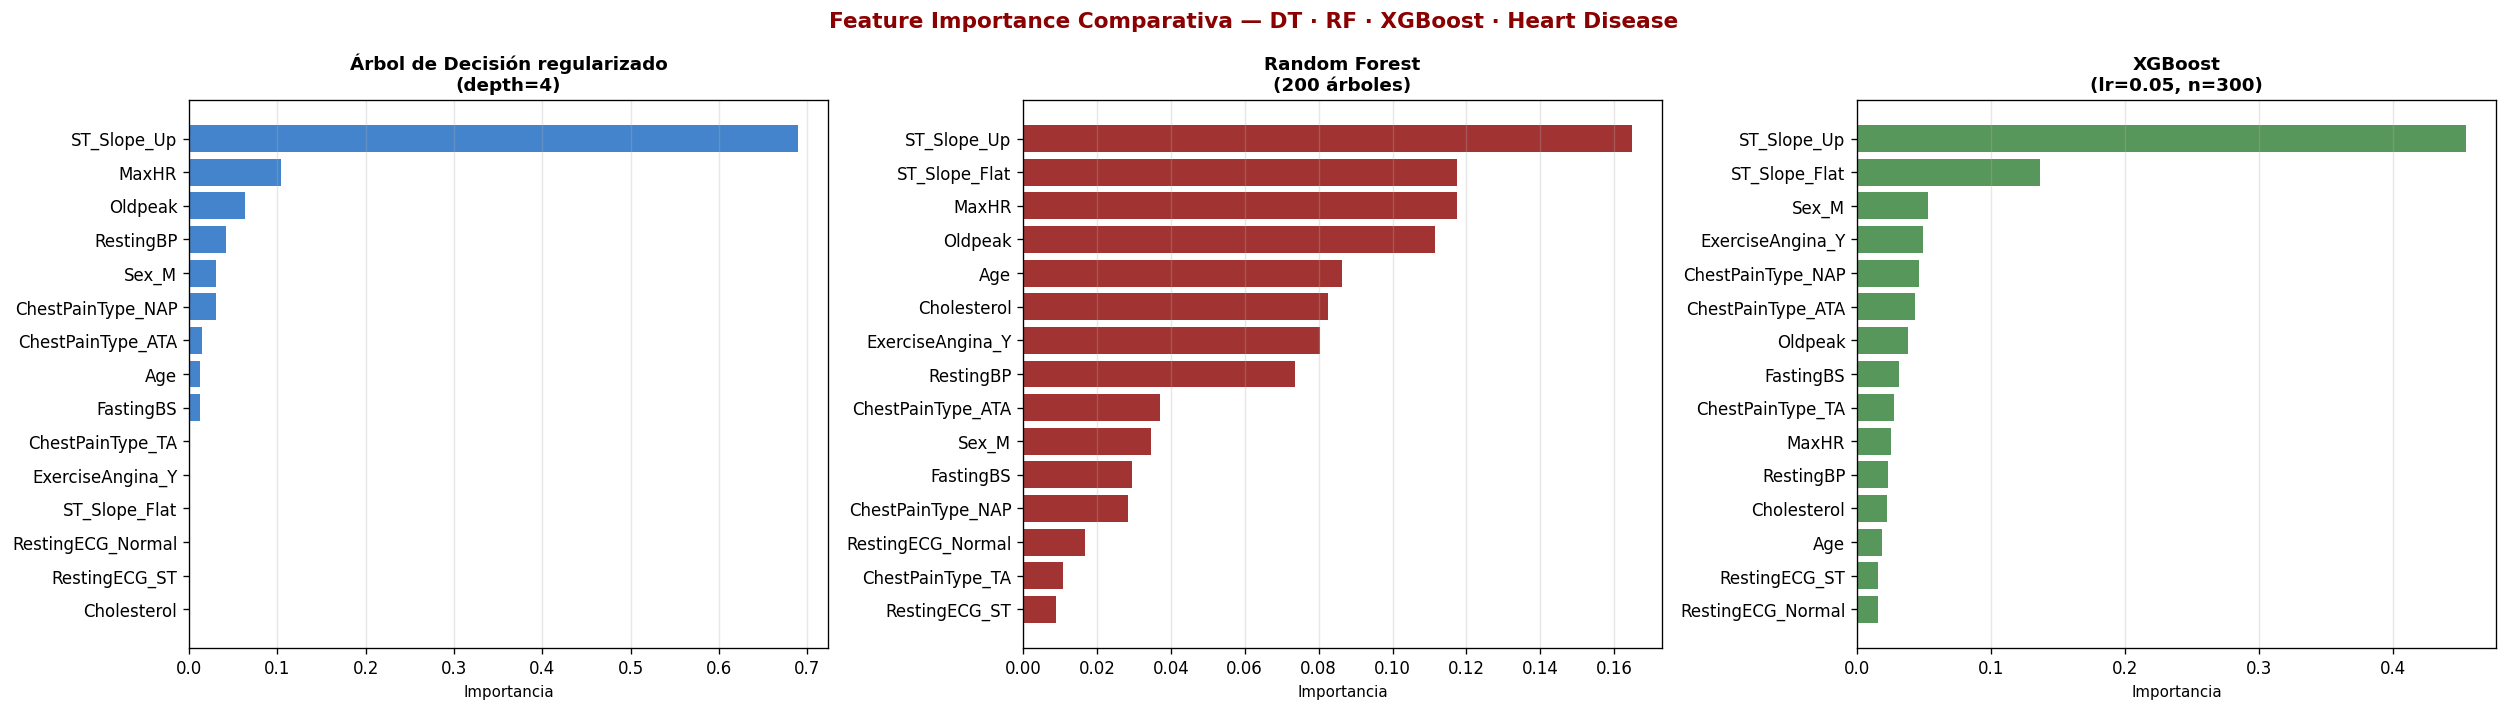

→ ¿Las tres metodologías coinciden en las features más importantes?
Inclusive si consideramos solo las 5 primeras características, podemos notar que solo coinciden en ST_Slope_Up en el primer lugar. 
Las demás características como MaxHR y OldPeak han sido relegadas por otras como ST_Slope Flat y Sex_M. 
Podemos ver por último que el modelo con más balance es RF a comparación del XGBoost final.


In [75]:
# ── Feature Importance: DT vs RF vs XGBoost ─────────────────────
# TODO 28: extrae las feature importances de xgb_final
importances_xgb = xgb_final.feature_importances_

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, imp, title, color in zip(
    axes,
    [importances_dt, importances_rf, importances_xgb],
    [f'Árbol de Decisión regularizado\n(depth={best_depth})',
     'Random Forest\n(200 árboles)',
     f'XGBoost\n(lr={best_lr}, n={best_n_xgb})'],
    [UPCH_BLUE, UPCH_RED, UPCH_GREEN]
):
    idx = np.argsort(imp)
    ax.barh([feature_names[i] for i in idx], imp[idx], color=color, alpha=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Importancia', fontsize=9)
    ax.grid(True, axis='x', alpha=0.3)

plt.suptitle('Feature Importance Comparativa — DT · RF · XGBoost · Heart Disease',
             fontsize=13, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('fi_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ ¿Las tres metodologías coinciden en las features más importantes?')
print('Inclusive si consideramos solo las 5 primeras características, podemos notar que solo coinciden en ST_Slope_Up en el primer lugar. \nLas demás características como MaxHR y OldPeak han sido relegadas por otras como ST_Slope Flat y Sex_M. \nPodemos ver por último que el modelo con más balance es RF a comparación del XGBoost final.')

---
# PARTE 4 — Comparación Final
## Ejercicio 6 — ROC curves y tabla de métricas

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>

### Paso 6.1 — Curvas ROC

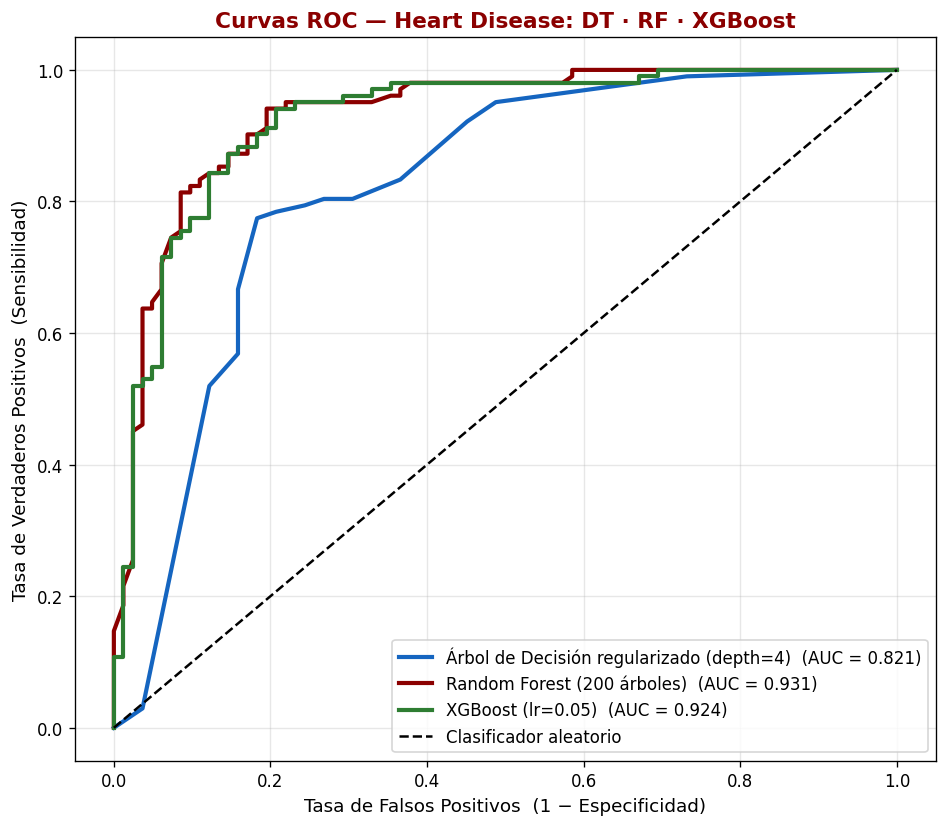

In [76]:
# ── Curvas ROC: DT, RF, XGBoost ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

for modelo, nombre, color in [
    (dt_opt,    f'Árbol de Decisión regularizado (depth={best_depth})', UPCH_BLUE),
    (rf_final,  'Random Forest (200 árboles)',              UPCH_RED),
    (xgb_final, f'XGBoost (lr={best_lr})',                 UPCH_GREEN)
]:
    # TODO 29: obtén las probabilidades de la clase positiva
    #   usa modelo.predict_proba(X_test)[:, 1]
    y_score = modelo.predict_proba(X_test)[:, 1]

    # TODO 30: calcula fpr, tpr con roc_curve y el AUC con auc()
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc     = auc(fpr, tpr)

    ax.plot(fpr, tpr, lw=2.5, color=color,
            label=f'{nombre}  (AUC = {roc_auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos  (1 − Especificidad)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos  (Sensibilidad)', fontsize=11)
ax.set_title('Curvas ROC — Heart Disease: DT · RF · XGBoost',
             fontsize=13, fontweight='bold', color=UPCH_RED)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()

### Paso 6.2 — Tabla de métricas comparativa

In [78]:
# ── Tabla de métricas comparativa ───────────────────────────────
print('=' * 75)
print('     RESUMEN FINAL — Challenge 4: Árboles, RF y XGBoost')
print('=' * 75)
print(f'{"Modelo":<30} {"Accuracy":<12} {"Recall":<12} {"Precision":<12} {"F1"}')
print('-' * 75)

# TODO 31: completa la tabla con los valores de acc, rec, prec, f1
#           para DT, RF y XGBoost
resultados = [
    (f'DT regularizado (d={best_depth})', acc_dt, rec_dt, prec_dt, f1_dt),
    ('Random Forest (n=200)',               acc_rf, rec_rf, prec_rf, f1_rf),
    (f'XGBoost (lr={best_lr})',             acc_xgb, rec_xgb, prec_xgb, f1_xgb),
]
for nombre, acc, rec, prec, f1 in resultados:
    print(f'{nombre:<30} {acc:.4f}       {rec:.4f}       {prec:.4f}       {f1:.4f}')

     RESUMEN FINAL — Challenge 4: Árboles, RF y XGBoost
Modelo                         Accuracy     Recall       Precision    F1
---------------------------------------------------------------------------
DT regularizado (d=4)          0.7772       0.7941       0.8020       0.7980
Random Forest (n=200)          0.8587       0.8725       0.8725       0.8725
XGBoost (lr=0.05)              0.8587       0.8431       0.8958       0.8687


### Paso 6.3 — Interpretación sesgo-varianza

**📝 Tu respuesta (edita esta celda):**

Completa la tabla:

| Modelo | Sesgo | Varianza | Mecanismo de reducción |
|---|---|---|---|
| Árbol profundo | Bajo | Alta | Ninguno |
| Árbol prepodado / profundidad controlada | Medio | Media |Menos complejidad|
| Random Forest | Bajo | Baja | Bagging |
| XGBoost | Muy bajo | Baja| Boosting|

**¿En qué escenario clínico usarías cada modelo? Justifica:**

- **Árbol de Decisión prepodado:** Derivación dentro de una posta médica, al ser una cantidad de servicios limitados serviría como guía al personal del establecimiento.
- **Random Forest:** Procesamiento y diagnóstico de señales/imágenes cardiacas, permite detectar ciertos detalles creando un modelo robusto de baja varianza y dando pesos similares a las características.
- **XGBoost:** Predicción de mortalidad en la población mayor de 60 años en Lima Metropolitana, permite usar varios features e ir mejorando el modelo poco a poco y aprendiendo de sus errores para obtener un valor mayor de accuracy.



---
<div style='background:#f5f5f5; padding:15px; border-left:5px solid #8B0000; border-radius:4px'>
<b>Entrega:</b> Sube tu notebook ejecutado (.ipynb con outputs) a tu carpeta de GitHub del curso.<br>
<b>Nombre del archivo:</b> <code>Challenge4_ApellidoNombreDeAmbos.ipynb</code><br>
<b>Fecha límite:</b> antes de Clase 6
</div>
